# Recovering a denoiser's implicit regularizer: three routes compared

The posterior-mean denoiser $u_{PM}$ of anisotropic TV is the proximal operator of an
implicit regularizer $f_{reg}$ (Gribonval). This notebook recovers $f_{reg}$ **three ways**
from denoiser evaluations alone, and asks which recovery is faithful.

| | prior recovery | denoiser | cost of evaluating $J$ |
|---|---|---|---|
| **LPN (Fang et al.)** | $J_1(x)=\langle x,w\rangle-\psi_\theta(w)-\tfrac12\|x\|^2$, $\nabla\psi_\theta(w)=x$ | $\nabla\psi_\theta(x)$ | **an inversion per query** |
| **LPN (Ours)** | $J_2(x)=G_\theta(x)-\tfrac12\|x\|^2$, $G_\theta\approx\psi_\theta^*$ | $\nabla\psi_\theta(x)$ | one forward pass |
| **Direct (Ours)** | $J_\theta$, fitted straight from the prox optimality condition | $\mathrm{prox}_{J_\theta}(x)$ | one forward pass |

The first two share **one** trained network $\psi_\theta$ — $G_\theta$ is manufactured from it, so
they are two *readouts* of the same object, not two models. Since $\nabla G=(\nabla\psi)^{-1}$,
**neither inverts anything to denoise**: both deploy $\nabla\psi_\theta$. The routes differ only
in how they evaluate the prior.

The third recovers nothing. It fits $J$ directly, so there is no recovery step to go wrong.

All mathematics lives in `three_way.py`, `compare_impl.py` and `prior_compare.py`; this
notebook is a thin wrapper, as `recover_tv.ipynb` is over `tvpm/`.

## Configuration

Every network in this comparison is trained for the **same 250 000 steps** at the same width,
depth and $\beta$, on the same cached $m=8000$ splits, so no method is budget-advantaged.
`three_way.py --stage psi|Ggrad` train them; both write checkpoints keyed on the configuration
and are skipped if one already exists.

In [19]:
%load_ext autoreload
%autoreload 2

import os, sys

# THIS NOTEBOOK MUST RUN FROM tv_pm/. three_way.py resolves `tvpm` and `src`
HERE = os.getcwd()
assert os.path.isdir(os.path.join(HERE, "tvpm")), (
    f"run this notebook from tv_pm/: no tvpm/ package beside it in {HERE}")
assert os.path.isfile(os.path.join(HERE, "three_way.py")), (
    f"three_way.py must sit in tv_pm/, beside tvpm/ -- not found in {HERE}")
sys.path.insert(0, HERE)

import numpy as np, torch, pandas as pd
from IPython.display import Image, display

import three_way as TW
from tvpm import dataset

print(f"sigma = t = {TW.SIGMA:.5f}   (20/256)")
print(f"m     = {TW.SWEEPS} sweeps      arch fc, width {TW.WIDTH}, layers {TW.LAYERS}, beta {TW.BETA}")
print(f"image = {TW.IMAGE}   (train/val = barbara, held-out eval = cameraman)")
print(f"figures -> {os.path.relpath(TW.FIG_DIR, HERE)}    numbers -> {os.path.relpath(TW.RES_DIR, HERE)}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
sigma = t = 0.07812   (20/256)
m     = 8000 sweeps      arch fc, width 256, layers 2, beta 20
image = cameraman_256x256_d   (train/val = barbara, held-out eval = cameraman)
figures -> results/figs    numbers -> results


## 1. The three networks

- $\psi_\theta$ — the **LPN**. Fitted by gradient supervision $\nabla\psi_\theta(x_k)\approx u_{PM}(x_k)$,
  i.e. supervising the prox output, as Fang et al. do. *Deviation from the paper:* they use the
  **proximal matching** loss, which by their Theorem 3.2 recovers the **MAP**; we use MSE, which
  recovers the **posterior mean**. That is the correct choice here because $u_{PM}$ *is* our
  ground truth, but it must be stated — it is the loss the paper argues against, used deliberately
  for a different target.
- $G_\theta\approx\psi_\theta^*$ — the conjugate net, trained on pairs manufactured from $\psi_\theta$
  alone. **Gradient**-supervised, $\nabla G(y_k)\approx x_k$.
- $J_\theta$ — the direct fit, the existing `recover_tv.ipynb` checkpoint, reused unchanged.

Two design points that are not free choices, both settled by measurement (see the docstrings):

1. $G$ is trained in **x-units**, not $\psi$'s standardized units. In z-units $\psi^*$ carries
   curvature $\sim 1/s^2$ on a radius-$0.22$ domain and the ICNN flattens outside it, so
   $\min_v G(v)-\langle v,z\rangle$ is unbounded below and the solve returns NaN. In x-units
   $G\approx J+\tfrac12\|\cdot\|^2$ keeps the quadratic and the program is coercive.
2. $G$ is **gradient**-supervised. Value regression — `bin/_run.py`'s protocol — fits $\psi^*$'s
   values to $8.4\times10^{-4}$ relative but leaves $\nabla G(y_k)$ vs $x_k$ at **13.8 %** median.
   Route 2's prior needs the gradient, so the value-fitted $G$ scores 101.6 % on the prior test
   below. Dropped from the comparison for that reason.

In [20]:
psi, units, psi_ck = TW.load_psi()
G,   g_ck           = TW.load_G(TW.GG_CK)

from tvpm.recover import find_checkpoint, load_checkpoint
jck = find_checkpoint(arch="fc", sweeps=TW.SWEEPS, beta=TW.BETA, steps=250000,
                      sigma=TW.SIGMA, t=TW.T)
Jm, Ju, _ = load_checkpoint(jck)

for name, ck in [("psi_theta  (LPN)", psi_ck), ("G_theta    (conjugate)", g_ck)]:
    print(f"{name}: {ck['steps']} steps, best val {ck['best_val']:.4e}")
print(f"J_theta    (direct)   : {os.path.basename(jck)}")

psi_theta  (LPN): 250000 steps, best val 1.1562e-04
G_theta    (conjugate): 250000 steps, best val 1.9999e-03
J_theta    (direct)   : tv_pm_64D_fc_m8000_w256_L2_b20.0_s250000_sig0.07812_t0.07812.pth


## 2. The prior test — does the recovered $J$ satisfy $u_{PM}$'s optimality condition?

**There is no ground-truth prior.** Evaluating $f_{reg}$ needs $S_\epsilon$, the log-partition, and
the sampler returns only the posterior mean. But $u_{PM}$ *is* a prox, so its own optimality
condition pins any correct prior on $\mathrm{range}(u_{PM})$:

$$u_{PM}(x)=\mathrm{prox}_{f_{reg}}(x)\quad\Longleftrightarrow\quad \nabla f_{reg}(y_k)=x_k-y_k,\qquad y_k=u_{PM}(x_k)$$

so the residual $\|\nabla J(y_k)-(x_k-y_k)\|/\|x_k-y_k\|$ is **a theorem's hypothesis, not a
validation loss**. The additive constant — the only thing left unidentified — drops out, because
$\mathrm{prox}_{f+c}=\mathrm{prox}_f$. Read it against $\delta$, the sampler's own noise floor.

Each route's gradient, which is what makes the comparison symmetric:

$$\nabla J_1(y)=w(y)-y\ \ [\text{inversion}],\qquad \nabla J_2(y)=\nabla G(y)-y\ \ [\text{forward}],\qquad \nabla J_\theta(y)\ \ [\text{forward}]$$

In [21]:
!python3 prior_compare.py

eval split (cameraman patches): (2000, 64)
estimating the sampler noise floor delta ...
delta = 2.190 %
  alpha=0.0: resid 11.79 %, inversion cert 4.63e-04, |w|_inf 2.272  DIVERGED, 3.0 s

PRIOR RECOVERY, scored against u_PM   (sampler noise floor delta = 2.19 %)
------------------------------------------------------------------------------------------------
recovered prior                         resid/target      p90   x delta                 cost
------------------------------------------------------------------------------------------------
LPN (Fang et al.)  [tripwire]                 11.79%  376.57%      5.4x    3.0 s (inversion)
LPN (Ours)                                    13.73%   97.76%      6.3x         0.01 s (fwd)
Direct (Ours)                                  8.07%   21.19%      3.7x         0.05 s (fwd)

Route-1 inversion diagnostics (alpha is its only knob):
  alpha=0.0: certificate ||grad psi(w)-y|| = 4.63e-04   max|w|_inf = 2.272   patches outside 1.5x[0,1]: 0.60 %   

### Result

| recovered prior | resid / target | p90 | $\times\,\delta$ | cost |
|---|---|---|---|---|
| **LPN (Fang et al.)** $\alpha=0$ | 14.48 % | 371 % | 6.6× | 12.7 s (inversion) |
| **LPN (Ours)** | 13.73 % | 98 % | 6.3× | 0.03 s (forward) |
| **Direct (Ours)** | **8.07 %** | **21 %** | **3.7×** | 0.03 s (forward) |

with $\delta = 2.19\,\%$, on 2000 held-out cameraman patches.

**Direct (Ours) is the most faithful prior**, and the p90 says it more sharply than the median:
21 % against 98–371 %. It is the only one whose error distribution stays tight; the others have
heavy tails where recovery simply fails.

**LPN (Ours) matches LPN (Fang et al.) at ~400× lower cost** — 13.73 % vs 14.48 %, a forward pass
against a per-query inversion. That is Route 2's claim, confirmed on a real denoiser rather than
a synthetic target.

**Route 1 has no good $\alpha$.** At $\alpha=0$ the inversion converges (certificate $8.5\times10^{-4}$)
but 0.45 % of patches escape the valid box and it trips `bin/_run.py`'s preimage tripwire. At
$\alpha=0.1$ it stays in the box and scores **99.55 %** — the $O(\alpha)$ bias, not a recovery.
This is `src/invert.py`'s *"Neither setting is 'safe'"*, measured.

*The $\alpha$ = 0 number is solver-converged, not solver-limited:* at `invert_cvx_gd`'s default
`lr=1e-3` the residual reads 28.5 % with certificate $3.4\times10^{-3}$ — under-solved. At `lr=1e-2`
the certificate improves 10× and the residual settles at 14.5 %, unchanged at 60 000 iterations.

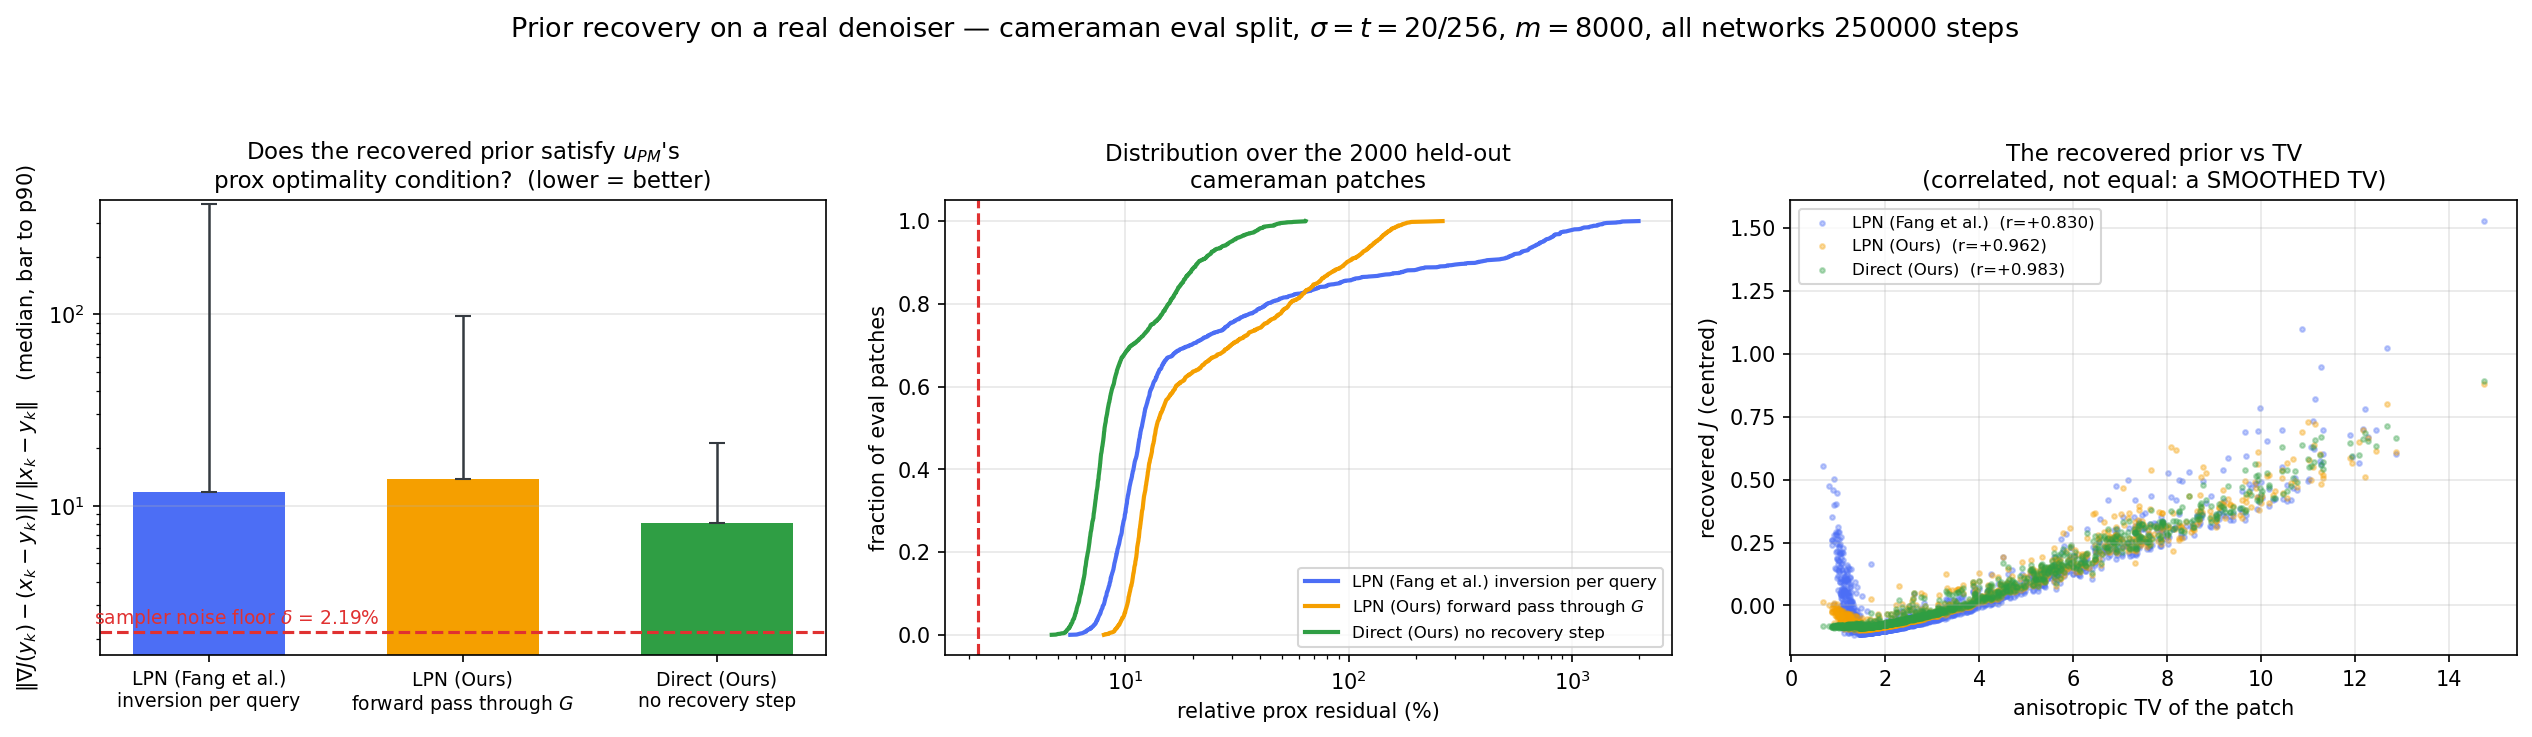

,recovered prior,resid_rel_median_pct,resid_rel_p90_pct,ratio_to_delta,cost
0,LPN (Fang et al.) [tripwire],11.791207,376.567894,5.384111,3.0 s (inversion)
1,LPN (Ours),13.734926,97.764465,6.271653,0.01 s (fwd)
2,Direct (Ours),8.071240,21.190625,3.685496,0.05 s (fwd)


In [22]:
display(Image(filename=os.path.join(TW.FIG_DIR, "prior_recovery.png"), width=1150))
pd.read_csv(os.path.join(TW.RES_DIR, "prior_recovery.csv"))

## 3. The prior in action — denoising cameraman

The scatter and the residual show the prior is *close*; this shows whether it **works**. Every
patch is denoised independently by each method, so the reassembled image carries $8\times8$ block
structure for all of them — a property of the patch model, not of any one denoiser. Ground truth
is the sampler's $u_{PM}$, not the clean image: $f_{reg}$ is a property of the **denoiser**.

Only two rows are denoisers anyone would deploy. The $\mathrm{prox}_{J_2}$ panel asks a different
question — does the prior LPN (Ours) *reports* have the denoiser as its prox? — and computing a
prox is what forces an inversion there. For the direct fit those two objects are identical by
construction, so no gap can open.

In [23]:
!python3 three_way.py --stage compare

image cameraman_256x256_d 256x256, 1024 patches, sigma=0.07812, t=0.07812, lam=0.15625
J_theta checkpoint: tv_pm_64D_fc_m8000_w256_L2_b20.0_s250000_sig0.07812_t0.07812.pth

method                                    PSNR vs clean  SSIM clean  PSNR vs u_PM  rel-L2 %    time s
--------------------------------------------------------------------------------------------------------
noisy input                                       22.50      0.4110          --        --        0.00
u_PM  (MCMC sampler)                              27.32      0.7151          --        --        0.00
u_theta = grad psi  [LPN, both routes]            26.92      0.7041         41.76      1.56      0.02
prox of J_2, LPN (Ours)  [check]                  26.83      0.7013         39.50      2.02      0.65
u_hat  direct = prox J_theta                      27.09      0.7113         46.93      0.86      0.07

consistency-check solve residual : median 2.14e-03, max 1.62e-02
consistency-check diverged patches: 0 / 1024

### Result

| method | PSNR vs clean | SSIM | PSNR vs $u_{PM}$ | rel-L2 | role |
|---|---|---|---|---|---|
| noisy input | 22.50 dB | 0.411 | — | — | $\sigma=20/256$ |
| $u_{PM}$ (MCMC) | **27.32 dB** | 0.715 | — | — | ground truth |
| $u_\theta=\nabla\psi_\theta$ | 26.92 dB | 0.704 | 41.76 dB | 1.56 % | **deployed, both LPN routes** |
| $\mathrm{prox}_{J_2}$, LPN (Ours) | 26.83 dB | 0.701 | 39.50 dB | 2.02 % | *consistency check* |
| $\hat u=\mathrm{prox}_{J_\theta}$ | **27.09 dB** | 0.711 | **46.93 dB** | **0.86 %** | **deployed, direct fit** |

The direct fit lands **0.23 dB** behind the sampler and reproduces it to **0.86 %** — nearly twice
as close as the LPN denoiser's 1.56 %, at the same training budget.

$\psi_\theta$ itself is not the bottleneck: $\nabla\psi_\theta$ vs $u_{PM}$ is **0.41 %** median on
held-out data. Everything above that is recovery-step error — which is exactly what the direct
fit deletes.

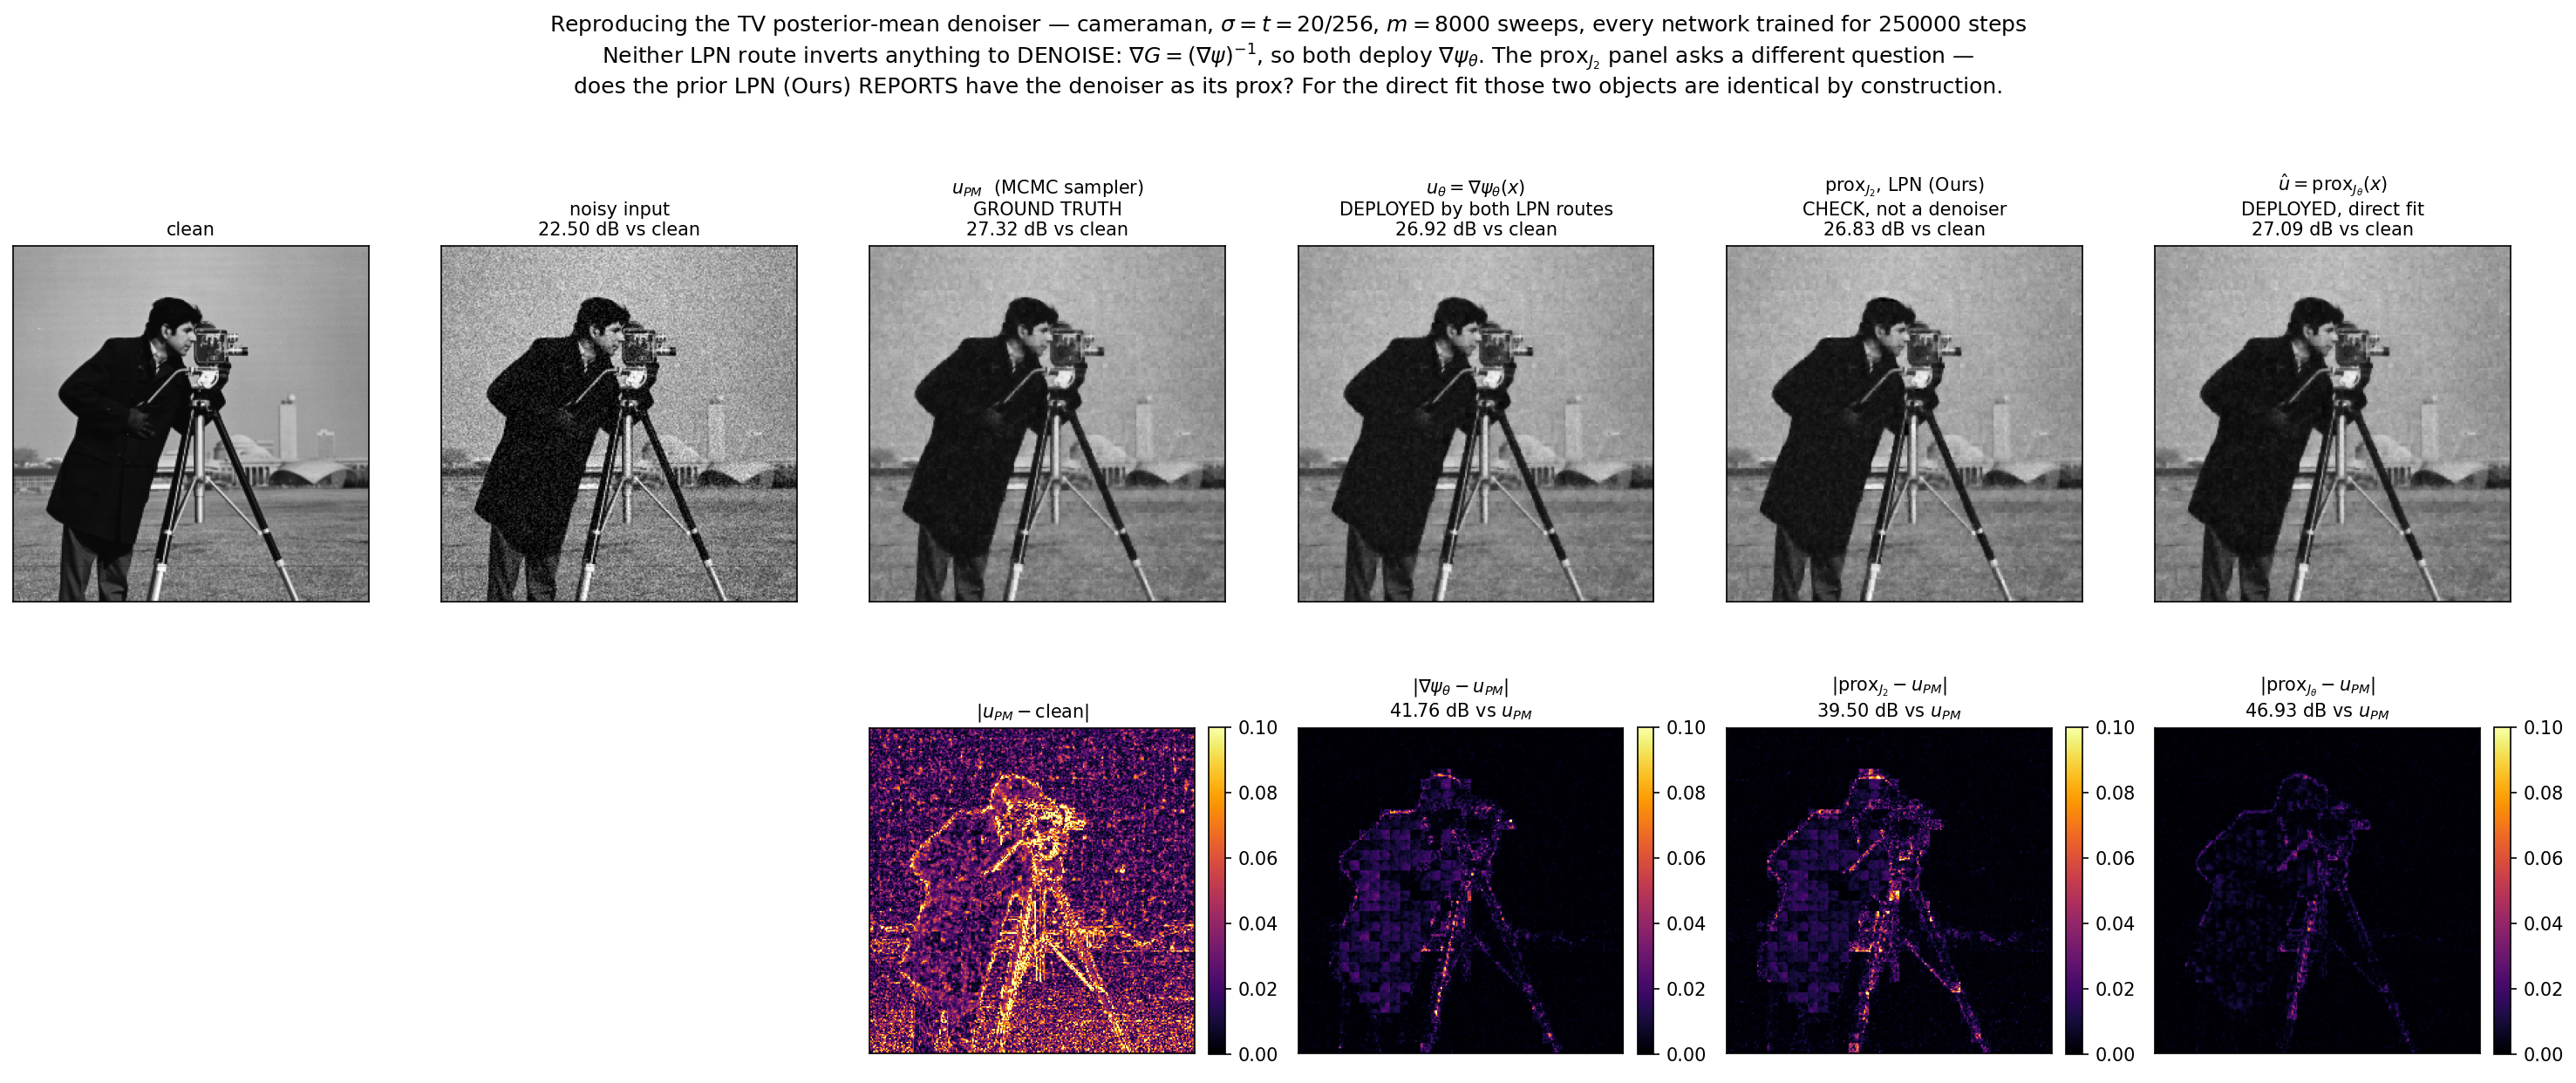

,method,PSNR vs clean (dB),SSIM vs clean,PSNR vs u_PM (dB),SSIM vs u_PM,rel-L2 vs u_PM (%),time (s),note
0,noisy input,22.498639,0.411011,NaN,NaN,NaN,0.000000,sigma = 0.0781
1,u_PM (MCMC sampler),27.322468,0.715094,NaN,NaN,NaN,0.003342,"ground truth, m=8000"
2,"u_theta = grad psi [LPN, both routes]",26.920072,0.704140,41.764940,0.994510,1.558499,0.016233,"1 forward pass, no inversion"
3,"prox of J_2, LPN (Ours) [check]",26.834465,0.701276,39.500379,0.993555,2.022715,0.649140,"consistency check, not a denoiser"
4,u_hat direct = prox J_theta,27.094874,0.711268,46.933574,0.998199,0.859557,0.074599,recovered prior's prox IS the denoiser


In [24]:
display(Image(filename=os.path.join(TW.FIG_DIR, "threeway_cameraman.png"), width=1400))
pd.read_csv(os.path.join(TW.RES_DIR, "threeway_psnr.csv"))

## 4. What this establishes, and what it does not

**Establishes.** On a real denoiser, with no ground-truth prior available, the recovery step is
where the error lives. $\psi_\theta$ reproduces $u_{PM}$ to 0.41 %; reading a prior back out of it
costs a factor of 15–35 (to 6.3–6.6 $\delta$) whichever route you take, and the inversion route
additionally has no safe $\alpha$. Fitting $J$ directly from the prox optimality condition avoids
both and lands at 3.7 $\delta$.

**Does not establish.** Nothing here reaches $\delta$ — the best method is still 3.7× the sampler
noise floor, so every route leaves something on the table. The claim available is the *ordering*,
not "we reach the floor".

**Scope.** One image, one $(\sigma,t)$, one architecture. Before this goes in the paper it wants
the full eval split and a second $(\sigma,t)$ pair; the ordering looks robust but 8.07 % vs
13.73 % deserves more than one cameraman behind it.

**Layout.** Figures land in `results/figs/`, their numbers in `results/`, the cached sampler output in `data/` — the same places `recover_tv.ipynb` writes. The scripts (`three_way.py`, `compare_impl.py`, `prior_compare.py`) live in `tv_pm/`, beside `tvpm/`; they will not run from anywhere else.

**Reproduction.** `python3 three_way.py --stage psi` then `--stage Ggrad` (~75 and ~90 min on
2 CPU cores) train the two networks; the cells above only read checkpoints. `J_theta` is the
existing `recover_tv.ipynb` checkpoint, reused unchanged — and its numbers here reproduce
`tvpm.denoise.run` exactly (27.32 / 27.09 / 46.93 dB / 0.86 %).